In [1]:
import cvxpy as cp
import cobra as cb
from cobra.util.array import create_stoichiometric_matrix
from cvxpylayers.torch import CvxpyLayer
import torch

# Load the model
# model = cb.io.load_json_model("../Cobra_Models/Univ_GPR_Model.json")
model = cb.io.load_json_model("../Cobra_Models/GPR_model_1a.json")
slack_penalty = 10  # Penalty for slack variables

# Extract the stoichiometric matrix and the bounds
S = create_stoichiometric_matrix(model, array_type="dok")
lower_bounds = model.reactions.list_attr("lower_bound")
upper_bounds = model.reactions.list_attr("upper_bound")

n_rxns = S.shape[1]
n_mets = S.shape[0]

# Define the optimization variables
v = cp.Variable(n_rxns)
slack_lb  = cp.Variable(n_rxns, nonneg=True)  # Slack variables for lower bounds
slack_ub = cp.Variable(n_rxns, nonneg=True)  # Slack variables for upper bounds

# add params for lower and upper bounds
lb = cp.Parameter(n_rxns)
ub = cp.Parameter(n_rxns)
lb.value = lower_bounds
ub.value = upper_bounds

# Define the constraints
constraints = [
    S @ v == 0,
    v >= lb - slack_lb,
    v <= ub + slack_ub
]

# Define the objective function (maximize the flux through the biomass reaction)
biomass_index = model.reactions.index("bio1(c)")
objective = cp.Maximize(v[biomass_index] - slack_penalty * (cp.sum(slack_lb) + cp.sum(slack_ub)))  # Penalize slack variables

# Define the optimization problem
problem = cp.Problem(objective, constraints)

# Create a CVXPY layer
layer = CvxpyLayer(problem, parameters=[lb, ub], variables=[v, slack_lb, slack_ub])

# Example input for the layer (using the original bounds)
input_lb = torch.tensor(lower_bounds)
input_ub = torch.tensor(upper_bounds)

# Forward pass through the layer
solution, slack_lb, slack_ub = layer(input_lb, input_ub)

# mapped back to reaction names
reaction_names = [rxn.id for rxn in model.reactions]
flux_dict = {reaction_names[i]: solution[i].item() for i in range(n_rxns)}
for rxn, flux in flux_dict.items():
    print(f"{rxn}: {flux}")


Set parameter Username
Set parameter LicenseID to value 2773321
Academic license - for non-commercial use only - expires 2027-02-01
EX_A(e): -500.00000214404804
EX_B(e): -500.0000021440261
T_A: 500.00000214250326
T_B: -500.0000021424813
T_Bio: 1000.0000042707077
AtoPrebio(c): 500.00000213942633
BtoPrebio(c): 500.00000213940467
bio1(c): 1000.0000042736118
EX_Bio(e): 1000.0000042692541


/home/rseag/anaconda3/envs/cvxm3/lib/python3.14/site-packages/cvxpylayers/torch/cvxpylayer.py:429: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1769687809709/work/aten/src/ATen/SparseCsrTensorImpl.cpp:49.)
  torch_csr = torch.sparse_csr_tensor(


In [2]:
import torch
from torch import nn
import torch.nn.functional as F

class ICNN_Block(nn.Module):
    """A standalone Input Convex Neural Network block."""
    def __init__(self, n_input, n_bounds, n_hidden_layers, hidden_layer_size):
        super(ICNN_Block, self).__init__()
        
        self.first_layer = nn.Linear(n_input, hidden_layer_size)
        
        self.z_layers = nn.ModuleList([
            nn.Linear(hidden_layer_size, hidden_layer_size, bias=False) 
            for _ in range(n_hidden_layers - 1)
        ])
        self.x_layers = nn.ModuleList([
            nn.Linear(n_input, hidden_layer_size, bias=True) 
            for _ in range(n_hidden_layers - 1)
        ])
        
        self.final_z = nn.Linear(hidden_layer_size, n_bounds, bias=False)
        self.final_x = nn.Linear(n_input, n_bounds, bias=True)

    def forward(self, x):
        z = F.relu(self.first_layer(x))
        
        for z_layer, x_layer in zip(self.z_layers, self.x_layers):
            z = F.relu(z_layer(z) + x_layer(x))
            
        return self.final_z(z) + self.final_x(x)

    def enforce_convexity(self):
        """Projects weights to non-negative orthant."""
        with torch.no_grad():
            for layer in self.z_layers:
                layer.weight.clamp_(min=0)
            self.final_z.weight.clamp_(min=0)


class FBA_Net(nn.Module):
    """Main network containing the two ICNN blocks and the CVXPY layer."""
    def __init__(self, cvxpylayer, n_input, n_bounds, n_hidden_layers, hidden_layer_size):
        super(FBA_Net, self).__init__()
        self.cvxpylayer = cvxpylayer
        
        # Instantiate two completely separate ICNN architectures
        self.lower_icnn = ICNN_Block(n_input, n_bounds, n_hidden_layers, hidden_layer_size)
        self.delta_icnn = ICNN_Block(n_input, n_bounds, n_hidden_layers, hidden_layer_size)

    def forward(self, x):
        # --- Independent ICNN Forward Passes ---
        # Both outputs will have shape: (batch_size, n_bounds)
        lb = self.lower_icnn(x)
        delta = self.delta_icnn(x)

        ub = lb + delta  # Ensure upper bound is always above lower bound
        
        # --- CVXPY Layer Pass ---
        # Pass the separated vectors directly to your cvxpylayer
        solution, slack_lb, slack_ub = self.cvxpylayer(lb, ub)
        
        return solution, slack_lb, slack_ub, lb, ub

    def enforce_convexity(self):
        """Call this after optimizer.step() to apply constraints to both blocks."""
        self.lower_icnn.enforce_convexity()
        self.delta_icnn.enforce_convexity()

class FBA_NET_Loss(nn.Module):
    """Custom loss function combining MSE and slack penalties."""
    def __init__(self, slack_loss_weight, sparse_bounds_weight):
        super(FBA_NET_Loss, self).__init__()
        self.slack_loss_weight = slack_loss_weight
        self.mse_loss = nn.MSELoss()
        self.sparse_bounds_weight = sparse_bounds_weight

    def forward(self, y_pred, y_true, slack_lb, slack_ub, lb, ub):
        self.mse_loss_val = self.mse_loss(y_pred, y_true)
        self.slack_penalty = self.slack_loss_weight * torch.mean(torch.sum(slack_lb + slack_ub, dim=1))
        self.sparse_bounds_loss = self.sparse_bounds_weight * torch.mean(torch.sum(torch.abs(lb) + torch.abs(ub), dim=1))
        return self.mse_loss_val + self.slack_penalty + self.sparse_bounds_loss
    
    def get_mse(self):
        return self.mse_loss_val.detach()
    
    def get_slack_penalty(self):
        return self.slack_penalty.detach()
    
    def get_sparse_bounds_loss(self):
        return self.sparse_bounds_loss.detach()
    

In [ ]:
# Example usage
import pandas as pd
import numpy as np

df = pd.read_csv("../Cobra_Models/simulated_data_mdl_1a.csv")

# columns are "g1", "g2", ..., "media1", "media2", ..., "flux"
# make useable for NN
x = df.drop(columns=["Objective"]).values  # shape: (num_samples, n_input)
y = df["Objective"].values  # shape: (num_samples,)

# Define the model
n_input = x.shape[1]
n_bounds = n_rxns  # number of reactions
n_hidden_layers = 2
hidden_layer_size = 32
model = FBA_Net(layer, n_input, n_bounds, n_hidden_layers, hidden_layer_size).double()
target_flux_idx = reaction_names.index("bio1(c)")  # Index of the biomass reaction in the solution vector

# Loss configs
slack_loss_weight = 50
sparse_bounds_weight = 5
crit = FBA_NET_Loss(slack_loss_weight=slack_loss_weight, sparse_bounds_weight=sparse_bounds_weight)

# training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
num_epochs = 250


# tracking
mse_losses = np.zeros(num_epochs)
slack_losses = np.zeros(num_epochs)
sparse_bounds_losses = np.zeros(num_epochs)

# training
for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()
    
    # Forward pass
    solution, slack_lb, slack_ub, lb, ub = model(torch.tensor(x, dtype=torch.double))
    
    y_pred = solution[:, target_flux_idx]  # Extract the predicted flux for the biomass reaction
    y_true = torch.tensor(y, dtype=torch.double)

    # Compute loss (MSE between predicted flux and true objective)
    loss = crit(y_pred, y_true,
                 slack_lb, slack_ub, 
                 lb, ub)

    # Backward pass and optimization step
    loss.backward()
    optimizer.step()
    
    # Enforce convexity constraints on the ICNN weights
    model.enforce_convexity()
    
    # report
    mse_losses[epoch] = crit.get_mse()
    slack_losses[epoch] = crit.get_slack_penalty()
    sparse_bounds_losses[epoch] = crit.get_sparse_bounds_loss()
    print(f"Epoch {epoch+1}/{num_epochs} | Loss: {loss.item():.4f} | MSE: {mse_losses[epoch]:.4f} | Slack: {slack_losses[epoch]:.4f} | Sparse Bounds: {sparse_bounds_losses[epoch]:.4f}")
    


Epoch 1/250 | Loss: 13390.5243 | MSE: 4568.4489 | Slack: 7272.3618 | Sparse Bounds: 1549.7135
Epoch 2/250 | Loss: 13317.6639 | MSE: 1896.6095 | Slack: 8006.6185 | Sparse Bounds: 3414.4358
Epoch 3/250 | Loss: 13045.2875 | MSE: 1839.8605 | Slack: 7803.5440 | Sparse Bounds: 3401.8830
Epoch 4/250 | Loss: 12764.5033 | MSE: 1793.0583 | Slack: 7588.9883 | Sparse Bounds: 3382.4567
Epoch 5/250 | Loss: 12504.9776 | MSE: 1768.6142 | Slack: 7376.7577 | Sparse Bounds: 3359.6058
Epoch 6/250 | Loss: 12277.3835 | MSE: 1775.6940 | Slack: 7167.7671 | Sparse Bounds: 3333.9223
Epoch 7/250 | Loss: 12049.2844 | MSE: 1783.0674 | Slack: 6961.8172 | Sparse Bounds: 3304.3997
Epoch 8/250 | Loss: 11817.8364 | MSE: 1786.9215 | Slack: 6758.5912 | Sparse Bounds: 3272.3237
Epoch 9/250 | Loss: 11588.9488 | MSE: 1790.1539 | Slack: 6560.0168 | Sparse Bounds: 3238.7781
Epoch 10/250 | Loss: 11386.3351 | MSE: 1796.7965 | Slack: 6386.4106 | Sparse Bounds: 3203.1280
Epoch 11/250 | Loss: 11195.0572 | MSE: 1810.2349 | Slack: 6

Text(0.5, 1.0, 'Slack Penalty')

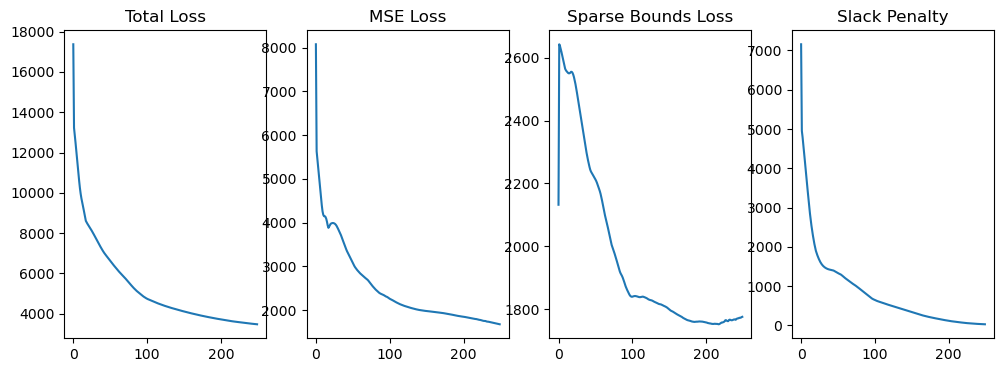

In [4]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 4, figsize=(12, 4))
axs = axs.flatten()
axs[0].plot(mse_losses+sparse_bounds_losses+slack_losses)
axs[0].set_title("Total Loss")
axs[1].plot(mse_losses, label="MSE Loss")
axs[1].set_title("MSE Loss")
axs[2].plot(sparse_bounds_losses, label="Sparse Bounds Loss")
axs[2].set_title("Sparse Bounds Loss")
axs[3].plot(slack_losses, label="Slack Penalty")
axs[3].set_title("Slack Penalty")

In [11]:
# test forward pass after training
eval_idx = 100

model.eval()
with torch.no_grad():
    solution, slack_lb, slack_ub, lb, ub = model(torch.tensor(x, dtype=torch.double))
    
    y_pred = solution[:, target_flux_idx]  # Extract the predicted flux for the biomass reaction
    y_true = torch.tensor(y, dtype=torch.double)

    # show predicted vs true fluxes
    print(f"Sample {eval_idx+1}: ")
    print(f"  y_pred = {y_pred[eval_idx].item():.4f}, y_true = {y_true[eval_idx].item():.4f}")
    print(f"  Slack:")
    print(f"    LB: {slack_lb[eval_idx].sum().item():.4f}")
    print(f"    UB: {slack_ub[eval_idx].sum().item():.4f}")
    for j in range(n_bounds):
        print(f"{reaction_names[j]} = {lb[eval_idx][j].item():.4f} to {ub[eval_idx][j].item():.4f}")

    # show sample features: Gene KO and media conditions
    print(f"  Features:")
    genes = [col for col in df.columns if col.startswith("G")]
    for j in range(len(genes)):
        if x[eval_idx][j] != 0:
            print(f"    {genes[j]}")
    print(f"   EX A = {x[eval_idx][len(genes)]:.4f}")
    print(f"   EX B = {x[eval_idx][len(genes)+1]:.4f}")

            
    


Sample 101: 
  y_pred = 79.8103, y_true = 164.9298
  Slack:
    LB: 0.0000
    UB: 0.0000
EX_A(e) = -65.8270 to -0.4347
EX_B(e) = -17.9145 to 0.2036
T_A = 2.1704 to 65.1592
T_B = -16.8850 to -0.3054
T_Bio = -0.2862 to 80.0059
AtoPrebio(c) = 12.4099 to 65.2563
BtoPrebio(c) = 8.6213 to 14.7265
bio1(c) = -0.2172 to 79.8103
EX_Bio(e) = 7.7040 to 79.8997
  Features:
    G6?
   EX A = -89.4975
   EX B = -75.4323


In [6]:
df


,G1?,G2?,G3?,G4?,G5?,G6?,EX_A(e),EX_B(e),Objective
0,0.0,0.0,1.0,0.0,0.0,0.0,-99.236734,-0.0,0.000000
1,0.0,0.0,0.0,1.0,0.0,0.0,-99.236734,-0.0,0.000000
2,1.0,0.0,0.0,0.0,0.0,0.0,-99.236734,-0.0,0.000000
3,0.0,0.0,0.0,0.0,1.0,0.0,-99.236734,-0.0,99.236734
4,0.0,0.0,0.0,0.0,0.0,1.0,-99.236734,-0.0,99.236734
...,...,...,...,...,...,...,...,...,...
595,0.0,0.0,0.0,1.0,0.0,0.0,-50.514540,-0.0,0.000000
596,1.0,0.0,0.0,0.0,0.0,0.0,-50.514540,-0.0,0.000000
597,0.0,0.0,0.0,0.0,1.0,0.0,-50.514540,-0.0,50.514540
598,0.0,0.0,0.0,0.0,0.0,1.0,-50.514540,-0.0,50.514540
